In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import re

In [2]:
def load_data():
    return pd.read_csv('Global_Smartwatch_Marketplace.csv')

df = load_data()

In [3]:
df

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...
...,...,...,...,...,...,...,...,...
3602,Apple,New,42.0,United States,424.97,Seller_1745,0,"Apple Watch Series 10 42mm Rose Gold Aluminum,..."
3603,Apple,New,46.0,United States,424.74,Seller_0249,0,Apple Watch Series 10 46mm GPS Cellular RoseGo...
3604,Apple,Used,46.0,United States,429.95,Seller_0694,0,Apple Watch Series 11 Titanium 46mm (GPS + Cel...
3605,Apple,Used,49.0,United States,424.50,Seller_0551,0,Apple Watch Ultra 2 49mm Titanium Case - Blue/...


In [4]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


In [5]:
df.sort_values(by='price', ascending=False, inplace=False)

df = df.drop(df.index[[2524, 1662]])


In [6]:
df_country = (df.groupby('Country')['price']
              .agg(['mean','median','count'])
             .sort_values(by='count', ascending=False)
             )

df_country


,mean,median,count
Country,,,
United States,591.441894,550.000,2344
United Kingdom,616.817740,515.000,469
South Korea,594.552453,553.940,212
Japan,566.228595,505.000,185
Italy,576.830076,593.990,131
Canada,640.928736,595.130,87
Germany,548.338919,520.000,37
Malaysia,597.716000,478.000,25
Hong Kong,442.277917,468.980,24


In [7]:
brands = ['Apple', 'Garmin', 'Samsung']

df_brand = df[df['brand'].isin(brands)]

top_countries = df_brand['Country'].value_counts().head(10).index

global_mean = df_brand['price'].mean()

mean_prices = (
    df_brand[df_brand['Country'].isin(top_countries)]
    .groupby(['Country', 'brand'])['price']
    .mean()
    .unstack()
)


counts = (
    df_brand.groupby(['Country', 'brand'])
    .size()
    .unstack()
)

mean_prices = mean_prices[counts >= 10]

(mean_prices - global_mean)/global_mean

brand,Apple,Garmin,Samsung
Country,,,
Australia,0.338349,NaN,NaN
Canada,0.035662,NaN,0.086400
Germany,-0.059966,-0.073556,NaN
Hong Kong,NaN,NaN,NaN
Italy,-0.009687,-0.046093,NaN
Japan,NaN,-0.037525,-0.180791
Malaysia,NaN,NaN,0.006587
South Korea,0.049346,NaN,-0.093779
United Kingdom,-0.282672,0.312829,0.331410


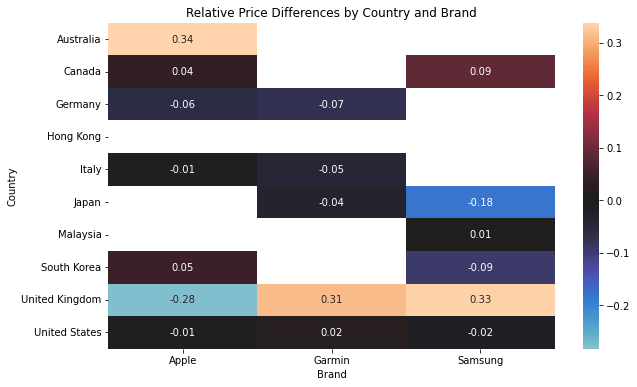

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    (mean_prices - global_mean)/global_mean,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    center=0             # center around 0 (important!)
)

plt.title('Relative Price Differences by Country and Brand')
plt.xlabel('Brand')
plt.ylabel('Country')

plt.show()

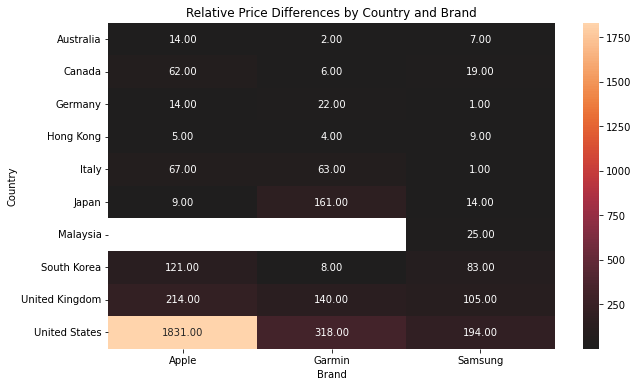

In [9]:
count_prices = (
    df_brand[df_brand['Country'].isin(top_countries)]
    .groupby(['Country', 'brand'])['price']
    .count()
    .unstack()
)


plt.figure(figsize=(10, 6))

sns.heatmap(
    count_prices,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    center=0             # center around 0 (important!)
)

plt.title('Relative Price Differences by Country and Brand')
plt.xlabel('Brand')
plt.ylabel('Country')

plt.show()

In [10]:
count_prices

brand,Apple,Garmin,Samsung
Country,,,
Australia,14.0,2.0,7.0
Canada,62.0,6.0,19.0
Germany,14.0,22.0,1.0
Hong Kong,5.0,4.0,9.0
Italy,67.0,63.0,1.0
Japan,9.0,161.0,14.0
Malaysia,NaN,NaN,25.0
South Korea,121.0,8.0,83.0
United Kingdom,214.0,140.0,105.0


In [11]:
df[df['Country'] == 'Malaysia']

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
443,Samsung,New,47.0,Malaysia,799.00,Seller_0170,1,Samsung Galaxy Watch Ultra 2025 47mm LTE GREY ...
454,Samsung,New,47.0,Malaysia,799.00,Seller_0170,1,Samsung Galaxy Watch Ultra 2025 47mm LTE WHITE...
472,Samsung,New,47.0,Malaysia,798.99,Seller_0176,1,Samsung Galaxy Watch Ultra 2025 47mm Android S...
474,Samsung,New,47.0,Malaysia,798.99,Seller_0176,1,Samsung Galaxy Watch Ultra 2025 47mm Android S...
489,Samsung,New,47.0,Malaysia,798.99,Seller_0176,1,Samsung Galaxy Watch Ultra 2025 47mm Android S...
521,Samsung,New,47.0,Malaysia,680.00,Seller_0192,1,NEW Samsung Galaxy Watch Ultra 2025 47mm LTE G...
525,Samsung,New,47.0,Malaysia,680.00,Seller_0192,1,NEW Samsung Galaxy Watch Ultra 2025 47mm LTE W...
526,Samsung,New,47.0,Malaysia,680.00,Seller_0192,1,NEW Samsung Galaxy Watch Ultra 2025 47mm LTE B...
536,Samsung,New,47.0,Malaysia,680.00,Seller_0192,1,NEW Samsung Galaxy Watch Ultra 2025 47mm LTE B...
1691,Samsung,New,47.0,Malaysia,799.00,Seller_0170,1,Samsung Galaxy Watch Ultra 2025 47mm LTE BLACK...


In [12]:
df.iloc[1234]['title']

'Apple Watch (Ultra 3) 49mm Black Titanium (LTE) w/ Tan Alpine Loop - Excellent'

In [13]:

BRAND_CONFIG = {
    "garmin": {
    "families": ["approach", "fenix", "venu", 
                 "forerunner", "instinct", "tactix", 
                 "descent", "epix", "quarix", "lily",
                "vivoactive", "tacx", "enduro"],
    "model_pattern": [
        r'gen\s?(\d+)',              # Gen 2
        r'\b(\d+[xs])\b',            # 7x, 7s
        r'\b([a-z]\d+)\b',           # S32
        r'(mk\s?\d+i?)',             # Mk2
        r'(mk\s?[ivx]+i?)',          # MkII
        r'(flux\s?[a-z])'
    ],
    "luxury_keywords": ["pro", "sapphire", "titanium", "solar"]
},
    
    "apple": {
    "families": ["series", "ultra", "se", 'hermes'],
    "model_pattern": [
        r'series\s?(\d+)',     # Series 10 → 10
        r'\bs(\d{1,2})\b',     # S8 → 8
        r'ultra\s?(\d*)',      # Ultra 2 → 2 (or empty)
        r'se\s?(\d*)',          # SE 2 → 2
        r'(\d+)'
    ],
    "luxury_keywords": ["ultra", "titanium"]
},
    
    "samsung": {
        "families": ["watch"],
        "model_pattern": [
            r'(ultra)',
            r'(\d+)',
            r'([a-z]\s?\d+)'
        ],
        "luxury_keywords": ["pro", "classic"]
},
    
    "xiaomi": {
        "families": ["watch"],
        "model_pattern": [
            r'([a-z]\d+)',
            r'([a-z]\s?\d+)',
            r'(\d+)'
        ],
        "luxury_keywords": ["pro", "classic"]
    }
}

In [14]:

def extract_features(row):
    title = str(row['title']).lower()
    brand = str(row['brand']).lower()
    
    # --- skip unknown brands ---
    if brand not in BRAND_CONFIG:
        return None, None, 0
    
    config = BRAND_CONFIG[brand]
    
    # --- FAMILY ---
    family = None
    for fam in config["families"]:
        if fam in title:
            family = fam
            break
    
    # --- MODEL NUMBER ---
    model = None
    
  
    if brand == "apple":
    
        # --- SPECIAL CASE: HERMES ---
        if "hermes" in title:
            family = "hermes"

        if family:
            for pattern in config["model_pattern"]:
                match = re.search(pattern, title)
                if match:
                    model = match.group(1)
                    break
    

    elif brand == "garmin":
        if family:
            start = title.find(family)
            sub = title[start:start + 40]

            model = None  # default

            # --- PRIORITY: family + number (e.g. "fenix 8")
            match = re.search(rf'{family}\s?(\d+)', sub)
            if match:
                candidate = match.group(1)

                # reject if it's part of measurement like "47mm"
                if not re.search(rf'{candidate}\s?(mm|cm|in|inch|")', sub):
                    model = candidate

            # --- FALLBACK: other patterns
            if model is None:
                for pattern in config["model_pattern"]:
                    match = re.search(pattern, sub)
                    if match:
                        candidate = match.group(1)

                        # reject measurement artifacts
                        if re.search(rf'{candidate}\s?(mm|cm|in|inch|")', sub):
                            continue

                        model = candidate
                        break
    

    elif brand == "samsung":
        for pattern in config["model_pattern"]:
            match = re.search(pattern, title)
            if match:
                # always use captured group (number only)
                model = match.group(1)
                break
    
    if brand == "xiaomi":
        for pattern in config["model_pattern"]:
            full_pattern = rf'{family}[\s\-]*{pattern}'
            match = re.search(full_pattern, title)
            if match:
                # always use captured group (number only)
                model = match.group(1)
                break
            
    
    # --- NORMALIZE MODEL ---
    if model:
        model = model.replace(" ", "").upper()
        
        # optional: normalize roman numerals (Garmin MKII → MK2)
        roman_map = {
            "III": "3",
            "II": "2",
            "IV": "4",
            "I": "1"
        }
        for r, d in roman_map.items():
            model = model.replace(r, d)
    
    # --- LUXURY FLAG ---
    luxury_flag = int(any(word in title for word in config["luxury_keywords"]))
    
    return family, model, luxury_flag

In [15]:
df[['family', 'model_number', 'luxury_flag']] = df.apply(
    extract_features,
    axis=1,
    result_type='expand'
)

In [16]:
df['model_full'] = (
    df['brand'] + "_" +
    df['family'].fillna("unknown") + "_" +
    df['model_number'].fillna("unknown")
)


df['model_full'] = df['model_full'].replace(
    r'.*_None$', '_unknown', regex=True
)

In [17]:
cat_cols = ['model_full', 'condition', 'Country']
num_cols = ['Case_Size_mm', 'luxury_flag']

In [18]:
# ----------------------------
# HANDLE MISSING VALUES
# ----------------------------

# Categorical columns
cat_cols = ['model_full', 'condition', 'Country']

for col in cat_cols:
    df[col] = df[col].fillna('unknown')

# Numerical columns
# Case size → use median (robust to outliers)
df['Case_Size_mm'] = df['Case_Size_mm'].fillna(df['Case_Size_mm'].median())

# luxury_flag → default to 0 (not luxury)
df['luxury_flag'] = df['luxury_flag'].fillna(0)

# Optional: ensure correct types
df['luxury_flag'] = df['luxury_flag'].astype(int)

# ----------------------------
# (Optional but recommended)
# Clean model_full if any weird null combos slipped in
# ----------------------------
df['model_full'] = df['model_full'].replace(
    r'.*_(None|nan)$', '_unknown', regex=True
)

# ----------------------------
# Drop rows where price is missing (can't train without target)
# ----------------------------
df = df[df['price'].notnull()]

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# ----------------------------
# FEATURES
# ----------------------------
cat_cols = ['model_full', 'condition', 'Country']
num_cols = ['Case_Size_mm', 'luxury_flag']

X = df[cat_cols + num_cols]
y = np.log1p(df['price'])  # log transform

# ----------------------------
# TRAIN TEST SPLIT
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# PREPROCESSOR (ONE-HOT)
# ----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# ----------------------------
# MODELS
# ----------------------------
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

# ----------------------------
# TRAIN + EVALUATE
# ----------------------------
results = {}

for name, reg in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', reg)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2}

# ----------------------------
# PRINT RESULTS
# ----------------------------
for name, metrics in results.items():
    print(f"{name}: RMSE={metrics['RMSE']:.3f}, R2={metrics['R2']:.3f}")

Ridge: RMSE=0.254, R2=0.257
Lasso: RMSE=0.266, R2=0.190
RandomForest: RMSE=0.221, R2=0.438
GradientBoosting: RMSE=0.251, R2=0.277
HistGradientBoosting: RMSE=0.232, R2=0.384


In [20]:
# ----------------------------
# FIT FINAL MODEL (choose best)
# ----------------------------
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

best_model.fit(X_train, y_train)

# ----------------------------
# GET FEATURE NAMES
# ----------------------------
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = list(cat_feature_names) + num_cols

# ----------------------------
# GET IMPORTANCES
# ----------------------------
importances = best_model.named_steps['model'].feature_importances_

# ----------------------------
# BUILD DF
# ----------------------------
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# ----------------------------
# VIEW TOP FEATURES
# ----------------------------
print(feat_imp.head(20))

                          feature  importance
164        Country_United Kingdom    0.106092
167                  Case_Size_mm    0.103347
136                 condition_New    0.049031
168                   luxury_flag    0.040478
165         Country_United States    0.030642
38       model_full_Apple_ultra_3    0.029551
141                condition_Used    0.020757
78   model_full_Garmin_instinct_2    0.020584
117    model_full_Samsung_watch_8    0.020377
23     model_full_Apple_series_10    0.019402
105   model_full_Samsung_watch_24    0.018919
87       model_full_Garmin_venu_2    0.018696
139            condition_Open box    0.017932
36       model_full_Apple_ultra_2    0.017734
24     model_full_Apple_series_11    0.016540
114    model_full_Samsung_watch_6    0.016279
110    model_full_Samsung_watch_4    0.015565
107    model_full_Samsung_watch_3    0.014879
111    model_full_Samsung_watch_5    0.014116
16          model_full_Apple_se_3    0.013984


In [21]:
vc = df['Seller_ID'].value_counts()

top20 = vc.head(1500)

result = pd.DataFrame({
    'count': top20,
    'percent': top20 / len(df)
})

print(sum(result['percent']))

0.9300970873786946


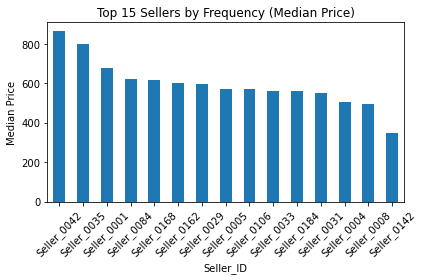

In [22]:

# Get top 15 most frequent Seller_IDs
top_sellers = df['Seller_ID'].value_counts().head(15).index

# Filter df to only those sellers
df_top = df[df['Seller_ID'].isin(top_sellers)]

# Compute median price per Seller_ID
median_prices = (
    df_top
    .groupby('Seller_ID')['price']
    .median()
    .sort_values(ascending=False)
)

# Plot
median_prices.plot(kind='bar')
plt.ylabel('Median Price')
plt.title('Top 15 Sellers by Frequency (Median Price)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
df[(df['family']=='instinct') & (df['model_number']=='2')].head(50)

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title,family,model_number,luxury_flag,model_full
109,Garmin,New,46.0,United Kingdom,955.00,Seller_0042,1,Garmin Instinct 2 Solar Tactical Edt Black Blu...,instinct,2,1,Garmin_instinct_2
114,Garmin,New,46.0,United Kingdom,955.00,Seller_0042,1,Garmin Instinct 2 Solar Surf Edt Green Bluetoo...,instinct,2,1,Garmin_instinct_2
115,Garmin,New,46.0,United Kingdom,955.00,Seller_0042,1,Garmin Instinct 2S Solar Surf Edt 32MB White B...,instinct,2,1,Garmin_instinct_2
118,Garmin,New,46.0,United Kingdom,955.00,Seller_0042,1,Garmin Instinct 2 Solar Tactical Edt Brown Blu...,instinct,2,1,Garmin_instinct_2
231,Garmin,New,46.0,United Kingdom,1299.00,Seller_0042,1,Garmin Instinct 2 Solar Tactical Edt Brown Blu...,instinct,2,1,Garmin_instinct_2
232,Garmin,New,46.0,United Kingdom,1299.00,Seller_0042,1,Garmin Instinct 2 Solar Tactical Edt Black Blu...,instinct,2,1,Garmin_instinct_2
235,Garmin,New,46.0,United Kingdom,1299.00,Seller_0042,1,Garmin Instinct 2 Solar Surf Edt Green Bluetoo...,instinct,2,1,Garmin_instinct_2
241,Garmin,New,46.0,United Kingdom,1299.00,Seller_0042,1,Garmin Instinct 2S Solar Surf Edt 32MB White B...,instinct,2,1,Garmin_instinct_2
282,Garmin,New,46.0,United Kingdom,865.00,Seller_0042,1,Garmin Instinct 2 Solar Std Edt Grey Bluetooth...,instinct,2,1,Garmin_instinct_2
284,Garmin,New,46.0,United Kingdom,865.00,Seller_0042,1,Garmin Instinct 2 Solar Std Edt Black Bluetoot...,instinct,2,1,Garmin_instinct_2


In [24]:
# Smoothed target encoding(te) for Seller_ID

# WARNING: only do this after train_test_split, after splitting data into folds, and then only use non-test folds to create encoding for test fold.
# It's called Out Of Fold (OOF) target encoding

counts = df['Seller_ID'].value_counts()     # Number of times a seller appears
m = 10                                 # Smoothing parameter. 10 is default
global_mean = df['price'].mean()
seller_mean = df.groupby('Seller_ID')['price'].mean()

l = counts/(counts + m) # This is the weight in (0,1). Sometimes other formulas are used but this one is simple

Seller_encoded = l*seller_mean + (1-l)*global_mean

df['seller_te'] = df['Seller_ID'].map(Seller_encoded)

In [25]:
counts_country = df['Country'].value_counts()     # Number of times a country appears
m = 10                                            #  Smoothing parameter. 10 is default
global_mean = df['price'].mean()
country_mean = df.groupby('Country')['price'].mean()

l_country = counts_country/(counts_country + m) # This is the weight in (0,1). Sometimes other formulas are used but this one is simple

country_encoded = l_country*country_mean + (1-l_country)*global_mean

df['country_te'] = df['Country'].map(country_encoded)



In [26]:
# Now we add a column that gives the log of the seller frequency

seller_counts = df['Seller_ID'].value_counts()
df['seller_freq_log'] = np.log1p( df['Seller_ID'].map(seller_counts)  )

In [27]:
df.head()

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title,family,model_number,luxury_flag,model_full,seller_te,country_te,seller_freq_log
0,Garmin,Used,46.0,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...,fenix,7,1,Garmin_fenix_7,644.052028,567.605908,4.189655
1,Garmin,Used,46.0,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...,descent,MK1,0,Garmin_descent_MK1,623.532921,567.605908,0.693147
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...,fenix,7,1,Garmin_fenix_7,644.052028,567.605908,4.189655
3,Garmin,New,46.0,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB,tactix,7,0,Garmin_tactix_7,648.260194,635.996517,0.693147
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...,descent,MK2,0,Garmin_descent_MK2,644.052028,567.605908,4.189655


In [28]:
df.groupby('Seller_ID')[['Seller_ID', 'seller_te', 'country_te', 'seller_freq_log']].mean().sort_values(by='seller_te', ascending=False)

,seller_te,country_te,seller_freq_log
Seller_ID,,,
Seller_0042,851.679362,616.342521,5.332719
Seller_0035,817.691727,591.448879,4.919981
Seller_0038,767.327589,590.886190,2.708050
Seller_0039,719.109537,591.448879,2.079442
Seller_0735,664.633010,719.514004,1.609438
...,...,...,...
Seller_0634,515.800758,616.322301,1.945910
Seller_0365,504.454441,567.605908,2.639057
Seller_0045,481.433071,486.633298,3.044522


In [32]:
df['price_log'] = np.log1p(df['price'])

In [30]:
df['condition'].unique()

array(['Used', 'New', 'Open box', 'For parts or not working',
       'Excellent - Refurbished', 'Caja abierta',
       'Very Good - Refurbished', 'Usado', 'Certified - Refurbished',
       'Nuevo', 'New other', 'Good - Refurbished', '--'], dtype=object)

In [34]:
condition_map= {
    'New':'New',
    'Nuevo':'New',
    'New other':'New',
    'Caja abierta':'Open box',
    'Open box':'Open box',
    'Usado':'Used',
    'Used':'Used',
    'Excellent - Refurbished':'Excellent - Refurbished',
    'Very Good - Refurbished':'Very Good - Refurbished',
    'Certified - Refurbished': 'Certified - Refurbished',
    'Good - Refurbished':'Good - Refurbished',
    'For parts or not working':'For parts or not working',
    '--':'Unknown'
}

df['condition_std'] = df['condition'].map(condition_map)



In [35]:
df[]

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title,family,model_number,luxury_flag,model_full,seller_te,country_te,seller_freq_log,condition_std,price_log
0,Garmin,Used,46.0,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...,fenix,7,1,Garmin_fenix_7,644.052028,567.605908,4.189655,Used,6.908515
1,Garmin,Used,46.0,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...,descent,MK1,0,Garmin_descent_MK1,623.532921,567.605908,0.693147,Used,6.834109
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...,fenix,7,1,Garmin_fenix_7,644.052028,567.605908,4.189655,Used,6.841530
3,Garmin,New,46.0,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB,tactix,7,0,Garmin_tactix_7,648.260194,635.996517,0.693147,New,7.090910
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...,descent,MK2,0,Garmin_descent_MK2,644.052028,567.605908,4.189655,Used,6.870136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3602,Apple,New,42.0,United States,424.97,Seller_1745,0,"Apple Watch Series 10 42mm Rose Gold Aluminum,...",series,10,0,Apple_series_10,565.066845,591.448879,1.098612,New,6.054369
3603,Apple,New,46.0,United States,424.74,Seller_0249,0,Apple Watch Series 10 46mm GPS Cellular RoseGo...,series,10,0,Apple_series_10,605.446785,591.448879,2.197225,New,6.053829
3604,Apple,Used,46.0,United States,429.95,Seller_0694,0,Apple Watch Series 11 Titanium 46mm (GPS + Cel...,series,11,1,Apple_series_11,547.190153,591.448879,1.609438,Used,6.065992
3605,Apple,Used,49.0,United States,424.50,Seller_0551,0,Apple Watch Ultra 2 49mm Titanium Case - Blue/...,ultra,2,1,Apple_ultra_2,544.553883,591.448879,1.945910,Used,6.053265


In [36]:
df['price'].describe()

count    3605.000000
mean      593.086214
std       178.449781
min       120.000000
25%       458.500000
50%       550.000000
75%       699.000000
max      1449.000000
Name: price, dtype: float64